# 🎬 Movie Success Prediction Project
This notebook builds a machine learning model to predict movie performance.


### 🔎 Step Explanation
This step performs part of the ML pipeline.


In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv("movies.csv")

## 📌 Problem Statement
Predict key outcomes like revenue or ROI using movie features.


### 🔎 Step Explanation
This step performs part of the ML pipeline.


In [7]:
df.isnull().sum()

budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64

## 📂 Data Loading


### 🔎 Step Explanation
This step performs part of the ML pipeline.


In [8]:
df = df[["budget", "revenue", "popularity", "vote_average"]]
df.isnull().sum()

budget          0
revenue         0
popularity      0
vote_average    0
dtype: int64

## 🔍 Exploratory Data Analysis (EDA)


### 🔎 Step Explanation
This step performs part of the ML pipeline.


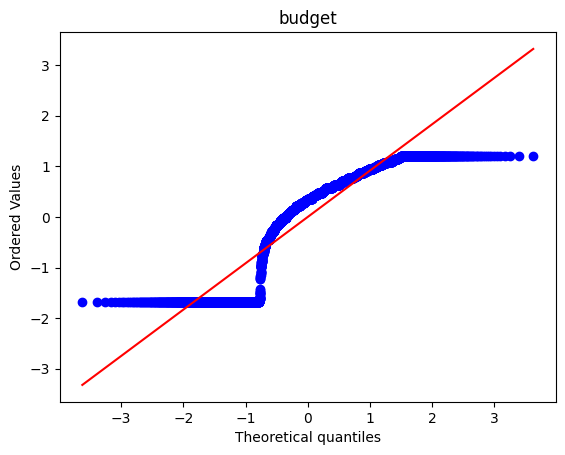

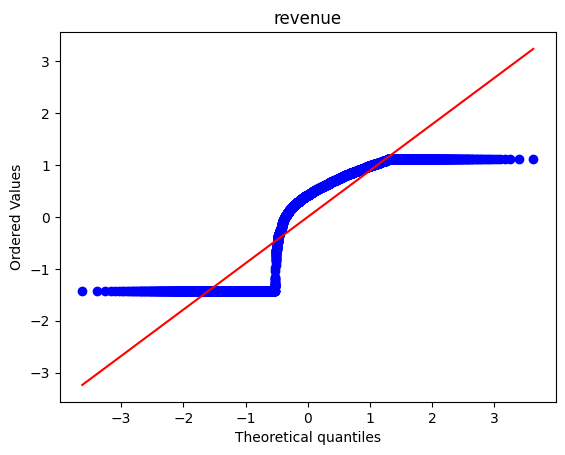

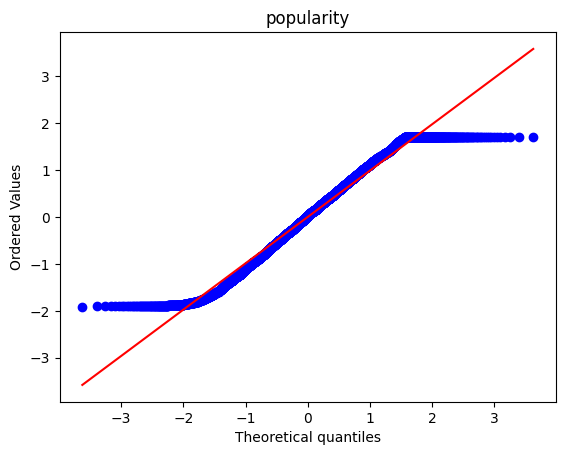

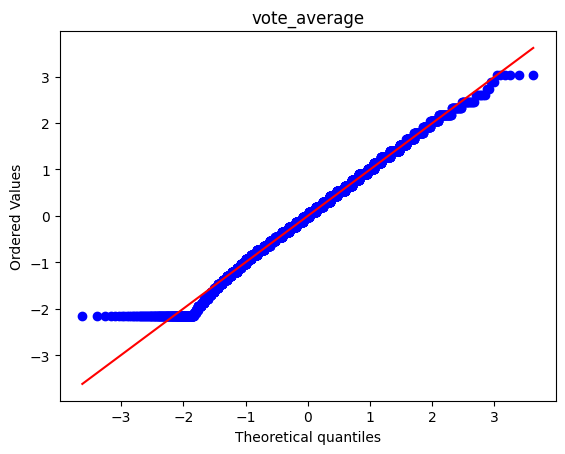

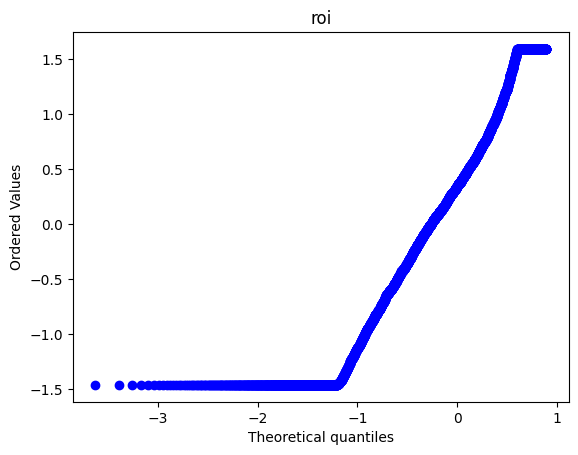

In [17]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

cols = ["budget","revenue","popularity","vote_average","roi"]

for col in cols:
    plt.figure()
    stats.probplot(df[col],dist="norm", plot=plt)
    plt.title(col)

## 🧹 Data Preprocessing
Includes missing value handling, outlier removal, and transformations.


### 🔎 Step Explanation
This step performs part of the ML pipeline.


In [10]:
roi = df["revenue"]/df["budget"]
df['roi'] = roi
df

,budget,revenue,popularity,vote_average,roi
0,237000000,2787965087,150.437577,7.2,11.763566
1,300000000,961000000,139.082615,6.9,3.203333
2,245000000,880674609,107.376788,6.3,3.594590
3,250000000,1084939099,112.312950,7.6,4.339756
4,260000000,284139100,43.926995,6.1,1.092843
...,...,...,...,...,...
4798,220000,2040920,14.269792,6.6,9.276909
4799,9000,0,0.642552,5.9,0.000000
4800,0,0,1.444476,7.0,NaN
4801,0,0,0.857008,5.7,NaN


## ⚙️ Feature Engineering


### 🔎 Step Explanation
This step performs part of the ML pipeline.


In [11]:
df.dropna()

,budget,revenue,popularity,vote_average,roi
0,237000000,2787965087,150.437577,7.2,11.763566
1,300000000,961000000,139.082615,6.9,3.203333
2,245000000,880674609,107.376788,6.3,3.594590
3,250000000,1084939099,112.312950,7.6,4.339756
4,260000000,284139100,43.926995,6.1,1.092843
...,...,...,...,...,...
4791,13,0,0.332679,2.0,0.000000
4792,20000,99000,0.212443,7.4,4.950000
4796,7000,424760,23.307949,6.9,60.680000
4798,220000,2040920,14.269792,6.6,9.276909


## 🤖 Model Building


### 🔎 Step Explanation
This step performs part of the ML pipeline.


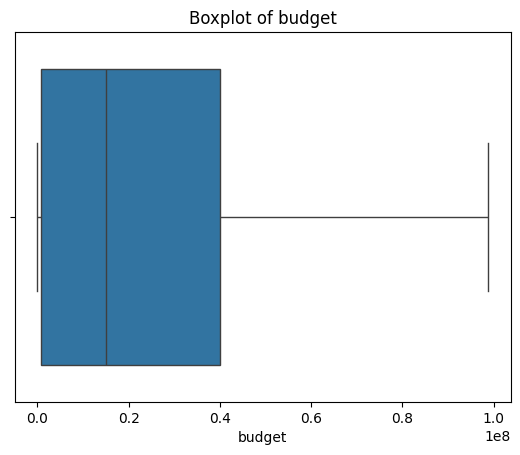

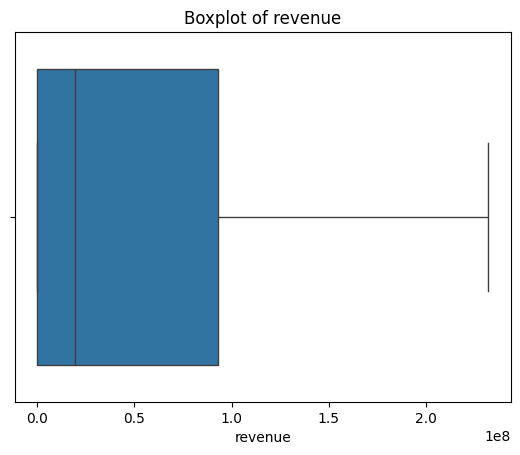

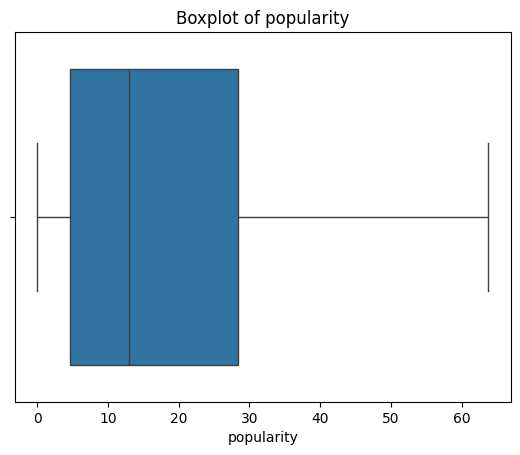

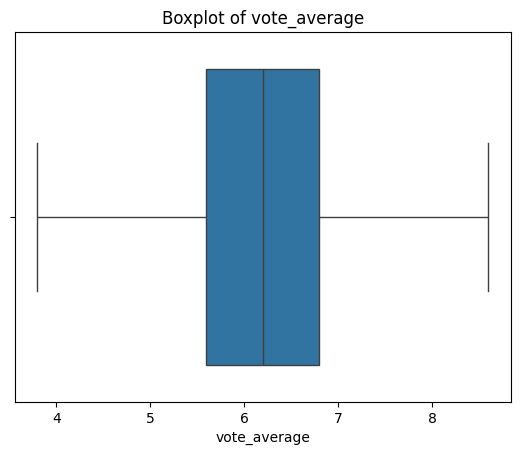

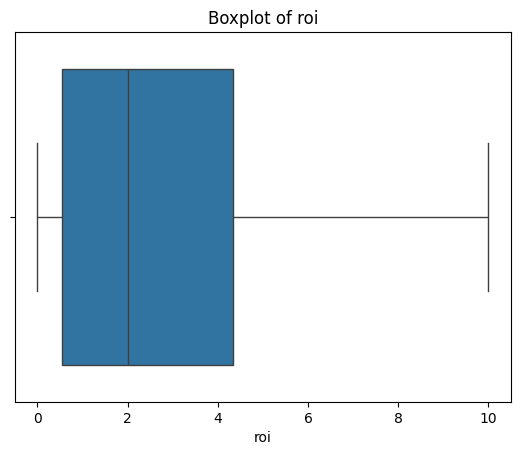

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ["budget","revenue","popularity","vote_average","roi"]

for col in cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## 📊 Model Evaluation


### 🔎 Step Explanation
This step performs part of the ML pipeline.


In [13]:
import numpy as np

cols = ["budget","revenue","popularity","vote_average","roi"]

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    upper_limit = Q3 + 1.5 * IQR
    lower_limit = Q1 - 1.5 * IQR
    
    df[col] = np.where(
        df[col] > upper_limit,
        upper_limit,
        np.where(
            df[col] < lower_limit,
            lower_limit,
            df[col]
        )
    )

## 🚀 Conclusion


### 🔎 Step Explanation
This step performs part of the ML pipeline.


In [16]:
from sklearn.preprocessing import PowerTransformer

cols = ["budget","revenue","popularity","vote_average","roi"]

pt = PowerTransformer(method='yeo-johnson')

df[cols] = pt.fit_transform(df[cols])

### 🔎 Step Explanation
This step performs part of the ML pipeline.


In [ ]:
df["roi"].skew()

### 🔎 Step Explanation
This step performs part of the ML pipeline.


In [18]:
df["roi"].describe()

count    3.913000e+03
mean    -7.808162e-17
std      1.000128e+00
min     -1.461926e+00
25%     -8.426998e-01
50%      4.242666e-02
75%      7.563593e-01
max      1.592284e+00
Name: roi, dtype: float64

### 🔎 Step Explanation
This step performs part of the ML pipeline.


In [22]:
df[["budget","revenue"]].skew()

budget    -0.743889
revenue   -0.544377
dtype: float64

### 🔎 Step Explanation
This step performs part of the ML pipeline.


In [23]:
df.to_csv("final_dataset.csv", index=False)

### 🔎 Step Explanation
This step performs part of the ML pipeline.


In [41]:
from sklearn.model_selection import train_test_split
X = df[["budget","popularity","vote_average","roi"]]  # features
y = df["revenue"]  # target

### 🔎 Step Explanation
This step performs part of the ML pipeline.


In [45]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

### 🔎 Step Explanation
This step performs part of the ML pipeline.


In [46]:
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.impute import SimpleImputer

# Create an imputer to replace NaN values with the mean of each column
imputer = SimpleImputer(strategy='mean')

# Apply the imputer to the training data
X_train_imputed = imputer.fit_transform(X_train)

# Now train the model with the imputed data
model = KNeighborsRegressor(n_neighbors=5)
model.fit(X_train_imputed, y_train)

# For prediction, you'll need to impute test data as well
#X_test_imputed = imputer.transform(X_test)
# predictions = model.predict(X_test_imputed)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### 🔎 Step Explanation
This step performs part of the ML pipeline.


In [47]:
df["roi"] = df["roi"].fillna(df["roi"].median())
df.isnull().sum()
df.isnull().mean() * 100  # percentage

budget          0.0
revenue         0.0
popularity      0.0
vote_average    0.0
roi             0.0
dtype: float64

### 🔎 Step Explanation
This step performs part of the ML pipeline.


In [48]:
df.isnull().sum()

budget          0
revenue         0
popularity      0
vote_average    0
roi             0
dtype: int64

### 🔎 Step Explanation
This step performs part of the ML pipeline.


In [49]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", KNeighborsRegressor(n_neighbors=5))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

### 🔎 Step Explanation
This step performs part of the ML pipeline.


In [56]:
from sklearn.metrics import r2_score

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.9507566186888312


### 🔎 Step Explanation
This step performs part of the ML pipeline.


In [57]:
from sklearn.metrics import mean_squared_error

print("MSE:", mean_squared_error(y_test, y_pred))

MSE: 0.05054897574932014


### 🔎 Step Explanation
This step performs part of the ML pipeline.


In [58]:
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 0.22483099374712584


### 🔎 Step Explanation
This step performs part of the ML pipeline.


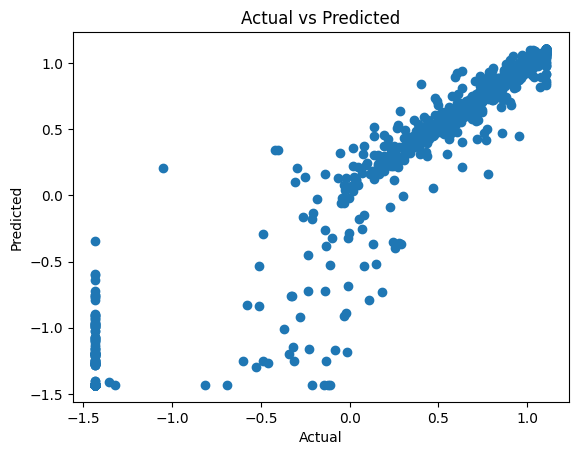

In [55]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

### 🔎 Step Explanation
This step performs part of the ML pipeline.


In [54]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 🔎 Step Explanation
This step performs part of the ML pipeline.
